# Neural Network Classifier & Regressor
### Seminário de Computação Quântica: Quantum Machine Learning (QML)

**Aluno:** Pedro Henrique Santos de Castro  
**Matrícula:** 202406840014  
**Tema (nº 1):** Neural Network Classifier & Regressor  
**Disciplina:** Computação Quântica

**Tutoriais-base (Qiskit Machine Learning):**
- *Quantum Neural Networks* (fundamentos): https://qiskit-community.github.io/qiskit-machine-learning/tutorials/01_neural_networks.html
- *Neural Network Classifier & Regressor* (tema): https://qiskit-community.github.io/qiskit-machine-learning/tutorials/02_neural_network_classifier_and_regressor.html

## 1. Configuração do ambiente

As bibliotecas foram instaladas com versões travadas para garantir a reprodutibilidade do notebook (`qiskit` 2.x e `qiskit-machine-learning` 0.9.0).

In [1]:
# Versões travadas para reprodutibilidade (Qiskit 2.x + qiskit-machine-learning 0.9.0)
!pip install -q qiskit==2.3.0 qiskit-machine-learning==0.9.0 pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_machine_learning.utils import algorithm_globals

# Semente fixa: garante resultados reproduzíveis
algorithm_globals.random_seed = 42

In [3]:
import sys, qiskit, qiskit_machine_learning, sklearn, numpy, matplotlib

print("Python                  :", sys.version.split()[0])
print("qiskit                  :", qiskit.__version__)
print("qiskit-machine-learning :", qiskit_machine_learning.__version__)
print("scikit-learn            :", sklearn.__version__)
print("numpy                   :", numpy.__version__)
print("matplotlib              :", matplotlib.__version__)

Python                  : 3.12.13
qiskit                  : 2.3.0
qiskit-machine-learning : 0.9.0
scikit-learn            : 1.6.1
numpy                   : 2.0.2
matplotlib              : 3.10.0


## 2. Introdução

### 2.1. O que é Quantum Machine Learning (QML)

O Quantum Machine Learning combina conceitos de computação quântica com técnicas
clássicas de aprendizado de máquina. A motivação é investigar se propriedades
quânticas, como superposição e emaranhamento, podem oferecer novas formas de
representar e processar dados, abrindo caminho para esquemas de aprendizado que
não teriam equivalente direto no mundo clássico.

### 2.2. Redes neurais quânticas (QNN) vs. redes clássicas

Uma rede neural clássica é formada por neurônios interconectados, organizados em
camadas, com parâmetros ajustáveis que são "aprendidos" durante o treinamento
para reconhecer padrões nos dados.

Uma rede neural quântica (QNN) segue a mesma ideia de parâmetros treináveis, mas
o modelo é implementado como um **circuito quântico parametrizado**. Esse circuito
tem duas partes:

- um **feature map**, que codifica os dados clássicos de entrada em um estado
  quântico, tipicamente usando ângulos de rotação das portas.
- um **ansatz** (ou forma variacional), cujas portas têm parâmetros treináveis,
  que funcionam como os "pesos" da rede.

O treinamento ajusta os pesos do ansatz para minimizar uma função de perda,
exatamente como em uma rede clássica, mas a função aprendida é avaliada por meio
da medição do circuito quântico.

### 2.3. As duas QNNs do `qiskit-machine-learning`

A biblioteca fornece duas implementações, que servem de bloco de construção para
todo o restante do notebook:

- **`EstimatorQNN`**: a saída é o **valor esperado** de um observável (um número
  real, em geral no intervalo [-1, +1]). É adequada para regressão e para
  classificação binária.
- **`SamplerQNN`**: a saída é a **distribuição de probabilidades** obtida ao medir
  o circuito, que pode ser pós-processada por uma função `interpret` (por exemplo,
  a paridade). É adequada para classificação, inclusive em múltiplas classes.

### 2.4. Aplicações e potencialidade futura

As QNNs são unidades genéricas. As mesmas estruturas são aplicadas em
classificação, regressão, modelos generativos (qGANs) e em métodos de kernel
quântico. O maior potencial está em problemas com estrutura intrinsecamente
quântica, como química e física quânticas, e em espaços de características de alta
dimensão, nos quais certos circuitos podem ser difíceis de simular classicamente.

Atualmente, porém, a tecnologia está na era **NISQ** (dispositivos ruidosos de
escala intermediária). O número de qubits é limitado, há ruído nas operações e
existem desafios de treinamento, como os *barren plateaus*. A vantagem prática
sobre métodos clássicos ainda não está demonstrada de forma geral. O avanço
esperado depende de correção de erros, de melhores ansätze e do crescimento do
hardware quântico.

## 3. Fundamentos das QNNs

Esta seção reproduz, de forma condensada, as ideias centrais do primeiro tutorial
(*Quantum Neural Networks*). O objetivo é entender as duas classes de QNN antes de
aplicá-las em classificação e regressão. Para ambas, o fluxo é o mesmo: construir
um circuito quântico parametrizado, instanciar a QNN, executar a passagem direta
(*forward*, que produz a previsão) e a passagem reversa (*backward*, que produz os
gradientes usados no treinamento).

### 3.1. EstimatorQNN

A `EstimatorQNN` recebe um circuito parametrizado e um observável, e retorna o
valor esperado desse observável. O circuito abaixo tem 1 qubit e dois parâmetros:
um representa a entrada da rede (`input1`) e o outro representa um peso treinável
(`weight1`).

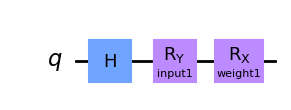

In [4]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.ry(params1[0], 0)
qc1.rx(params1[1], 0)
qc1.draw("mpl", style="clifford")

O observável define qual quantidade é medida para gerar a saída. Aqui é usado o
observável $Y$ aplicado a todos os qubits. Em seguida a `EstimatorQNN` é instanciada,
indicando qual parâmetro é entrada e qual é peso, e usando o `StatevectorEstimator`
para simulação local por vetor de estado.

In [5]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN

observable1 = SparsePauliOp.from_list([("Y" * qc1.num_qubits, 1)])

estimator = Estimator()
estimator_qnn = EstimatorQNN(
    circuit=qc1,
    observables=observable1,
    input_params=[params1[0]],
    weight_params=[params1[1]],
    estimator=estimator,
)
estimator_qnn

Em um cenário real, as entradas viriam do conjunto de dados e os pesos do
treinamento. Para ilustrar, são gerados valores aleatórios com a dimensão correta.
A passagem direta retorna um arranjo de formato `(batch_size, num_observables)`.

In [6]:
estimator_qnn_input = algorithm_globals.random.random(estimator_qnn.num_inputs)
estimator_qnn_weights = algorithm_globals.random.random(estimator_qnn.num_weights)

estimator_qnn_forward = estimator_qnn.forward(estimator_qnn_input, estimator_qnn_weights)
print(f"Entradas: {estimator_qnn.num_inputs} | Pesos: {estimator_qnn.num_weights}")
print(f"Resultado da forward pass: {estimator_qnn_forward}")
print(f"Formato: {estimator_qnn_forward.shape}")

Entradas: 1 | Pesos: 1
Resultado da forward pass: [[0.29427702]]
Formato: (1, 1)


A passagem reversa retorna os gradientes em relação aos pesos, que são o que um
otimizador usa para ajustar o modelo. Por padrão, apenas os gradientes dos pesos
são calculados.

In [7]:
estimator_qnn_input_grad, estimator_qnn_weight_grad = estimator_qnn.backward(
    estimator_qnn_input, estimator_qnn_weights
)
print(f"Gradientes dos pesos: {estimator_qnn_weight_grad}")
print(f"Formato: {estimator_qnn_weight_grad.shape}")

Gradientes dos pesos: [[[0.63272767]]]
Formato: (1, 1, 1)


### 3.2. SamplerQNN

A `SamplerQNN` é instanciada de forma parecida, mas não precisa de observável, pois
consome diretamente as amostras da medição do circuito. Por padrão, a saída é
interpretada como as probabilidades de medir cada bitstring. O circuito abaixo tem
2 qubits, com 2 parâmetros de entrada e 4 pesos treináveis.

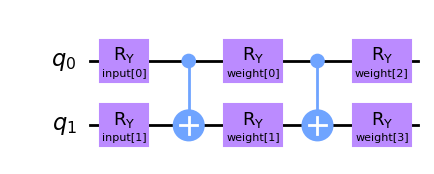

In [8]:
from qiskit.circuit import ParameterVector

inputs2 = ParameterVector("input", 2)
weights2 = ParameterVector("weight", 4)

qc2 = QuantumCircuit(2)
qc2.ry(inputs2[0], 0)
qc2.ry(inputs2[1], 1)
qc2.cx(0, 1)
qc2.ry(weights2[0], 0)
qc2.ry(weights2[1], 1)
qc2.cx(0, 1)
qc2.ry(weights2[2], 0)
qc2.ry(weights2[3], 1)

qc2.draw("mpl", style="clifford")

In [9]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN

sampler = Sampler()
sampler_qnn = SamplerQNN(
    circuit=qc2,
    input_params=inputs2,
    weight_params=weights2,
    sampler=sampler,
)
sampler_qnn

Sem uma função `interpret`, o formato esperado da saída é `(batch_size, 2**num_qubits)`,
ou seja, uma probabilidade para cada bitstring possível.

In [10]:
sampler_qnn_input = algorithm_globals.random.random(sampler_qnn.num_inputs)
sampler_qnn_weights = algorithm_globals.random.random(sampler_qnn.num_weights)

sampler_qnn_forward = sampler_qnn.forward(sampler_qnn_input, sampler_qnn_weights)
print(f"Entradas: {sampler_qnn.num_inputs} | Pesos: {sampler_qnn.num_weights}")
print(f"Resultado da forward pass: {sampler_qnn_forward}")
print(f"Formato: {sampler_qnn_forward.shape}")

Entradas: 2 | Pesos: 4
Resultado da forward pass: [[0.02050781 0.26171875 0.51171875 0.20605469]]
Formato: (1, 4)


In [11]:
sampler_qnn_input_grad, sampler_qnn_weight_grad = sampler_qnn.backward(
    sampler_qnn_input, sampler_qnn_weights
)
print(f"Gradientes dos pesos: {sampler_qnn_weight_grad}")
print(f"Formato: {sampler_qnn_weight_grad.shape}")

Gradientes dos pesos: [[[ 0.00488281 -0.11425781 -0.07958984 -0.11279297]
  [ 0.22119141 -0.09375     0.07470703 -0.21630859]
  [-0.48535156  0.31884766 -0.31640625  0.10302734]
  [ 0.25927734 -0.11083984  0.32128906  0.22607422]]]
Formato: (1, 4, 4)


Estes são os blocos básicos das QNNs. Nas próximas seções, em vez de entradas e
pesos aleatórios, os pesos passam a ser ajustados automaticamente por um otimizador
para resolver tarefas reais de classificação e regressão.

## 4. Classificação

Esta seção aplica as QNNs em tarefas de classificação. Primeiro é preparado um
conjunto de dados simples para ilustrar os algoritmos. São gerados 20 pontos com
2 atributos cada, no intervalo [-1, 1]. O rótulo de cada ponto é definido pelo
sinal da soma dos seus atributos, o que separa as duas classes por uma reta
diagonal (a linha tracejada do gráfico). São criadas três versões do rótulo,
usadas pelos diferentes algoritmos adiante: `y01` em {0, 1}, `y` em {-1, +1} e
`y_one_hot` na codificação one-hot.

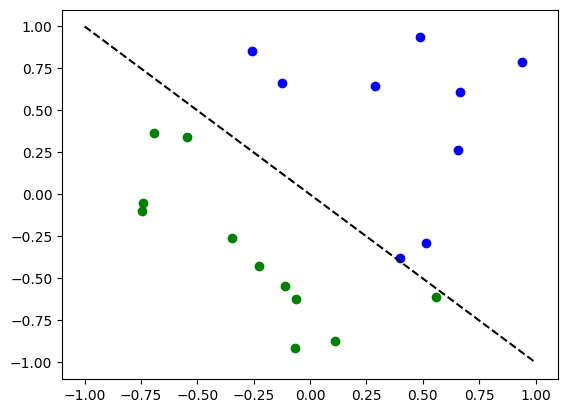

In [12]:
resultados_classificacao = {}  # guarda a acurácia de cada classificador

num_inputs = 2
num_samples = 20
X = 2 * algorithm_globals.random.random([num_samples, num_inputs]) - 1
y01 = 1 * (np.sum(X, axis=1) >= 0)  # rótulos em {0, 1}
y = 2 * y01 - 1  # rótulos em {-1, +1}
y_one_hot = np.zeros((num_samples, 2))
for i in range(num_samples):
    y_one_hot[i, y01[i]] = 1

for x, y_target in zip(X, y):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### 4.1. Classificação com `EstimatorQNN`

O primeiro algoritmo usa uma `EstimatorQNN` dentro de um `NeuralNetworkClassifier`.
Nesse contexto, a `EstimatorQNN` retorna uma saída em [-1, +1], adequada para
classificação binária, em que as duas classes são associadas a -1 e +1. Para montar
o circuito parametrizado a partir de um feature map e de um ansatz de forma prática,
é usada a função `qnn_circuit`, que por padrão combina o feature map `zz_feature_map`
com o ansatz `real_amplitudes`.

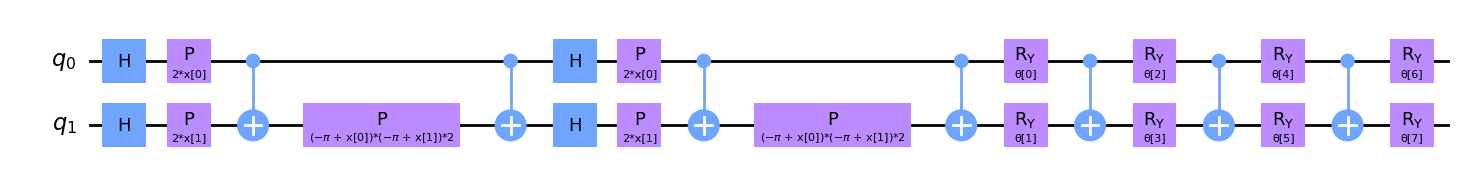

In [13]:
from qiskit_machine_learning.circuit.library import qnn_circuit

qc, fm_params, anz_params = qnn_circuit(num_qubits=2)
qc.draw("mpl", style="clifford")

A `EstimatorQNN` é criada a partir desse circuito, indicando os parâmetros de
entrada (`fm_params`, do feature map) e os de peso (`anz_params`, do ansatz). Como
antes, a simulação é local, via `StatevectorEstimator`. A célula seguinte confirma
que a QNN mapeia uma entrada para um valor em [-1, +1].

In [14]:
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN

estimator = Estimator()
estimator_qnn = EstimatorQNN(
    circuit=qc, input_params=fm_params, weight_params=anz_params, estimator=estimator
)

In [15]:
# a QNN mapeia as entradas para o intervalo [-1, +1]
estimator_qnn.forward(X[0, :], algorithm_globals.random.random(estimator_qnn.num_weights))

array([[0.76026888]])

Antes de treinar, é definida uma função de *callback*, chamada a cada iteração do
otimizador. Ela recebe os pesos atuais e o valor da função objetivo, e atualiza um
gráfico de função objetivo por iteração, o que permite acompanhar a convergência do
treinamento em tempo real.

In [16]:
from IPython.display import clear_output

def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Valor da função objetivo por iteração")
    plt.xlabel("Iteração")
    plt.ylabel("Valor da função objetivo")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

O `NeuralNetworkClassifier` envolve a QNN e define o otimizador. Aqui é usado o
`COBYLA` com no máximo 60 iterações.

In [17]:
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import COBYLA

estimator_classifier = NeuralNetworkClassifier(
    estimator_qnn, optimizer=COBYLA(maxiter=60), callback=callback_graph
)

O treinamento é feito com `fit`. Durante o processo, o gráfico da função objetivo é
atualizado pelo callback. Ao final, `score` retorna a acurácia no conjunto de treino.

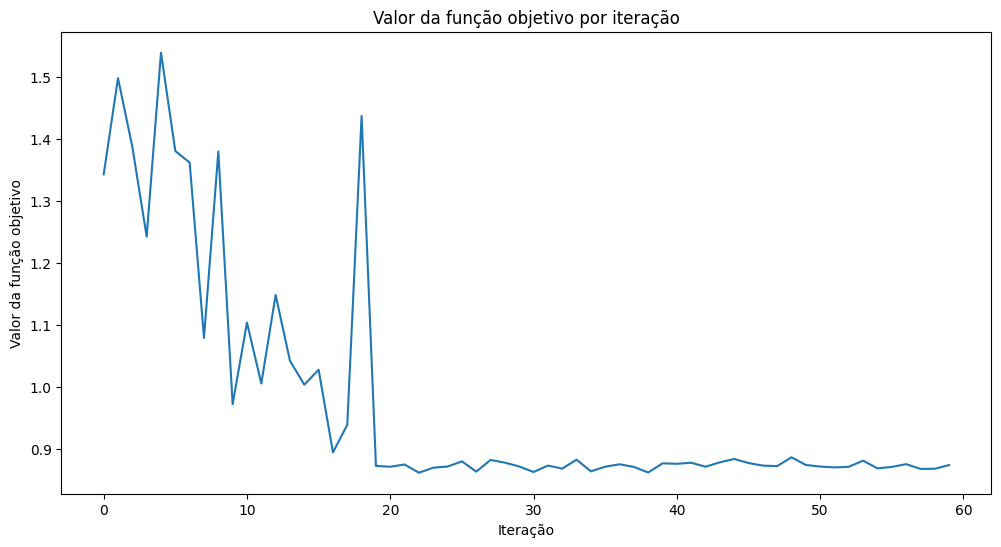

Acurácia no treino (EstimatorQNN): 70.0%


In [18]:
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

estimator_classifier.fit(X, y)

plt.rcParams["figure.figsize"] = (6, 4)

acc = estimator_classifier.score(X, y)
resultados_classificacao["EstimatorQNN"] = acc
print(f"Acurácia no treino (EstimatorQNN): {acc:.1%}")

Para visualizar o resultado, os pontos são plotados novamente. Os classificados
incorretamente são destacados com um círculo vermelho.

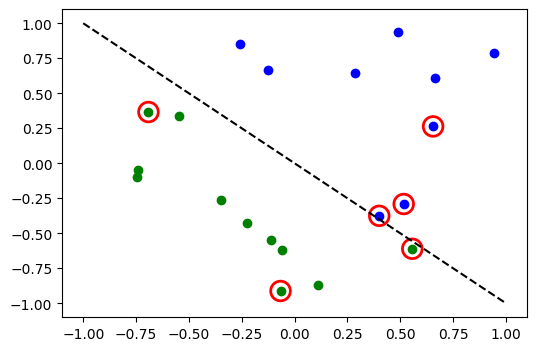

In [19]:
y_predict = estimator_classifier.predict(X)

for x, y_target, y_p in zip(X, y, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

Após o treino, é possível inspecionar os pesos ajustados da rede. A quantidade de
pesos é definida pelo ansatz.

In [20]:
estimator_classifier.weights

array([ 0.31612594,  0.76326301,  0.54921588, -1.0300243 ,  0.02204914,
        0.6505085 ,  2.3828968 ,  0.04972763])

### 4.2. Classificação com `SamplerQNN`

A `SamplerQNN` também pode ser usada em um `NeuralNetworkClassifier`. Diferente da
`EstimatorQNN`, a sua saída é a distribuição de probabilidades das bitstrings medidas.
Para classificação binária, é aplicada uma função de **paridade**, que mapeia cada
bitstring para 0 ou 1 conforme o número de bits 1 seja par ou ímpar. Aqui o circuito é
montado com `qnn_circuit`, mas com um ansatz `real_amplitudes` customizado com `reps=1`
(menos camadas, e portanto menos pesos).

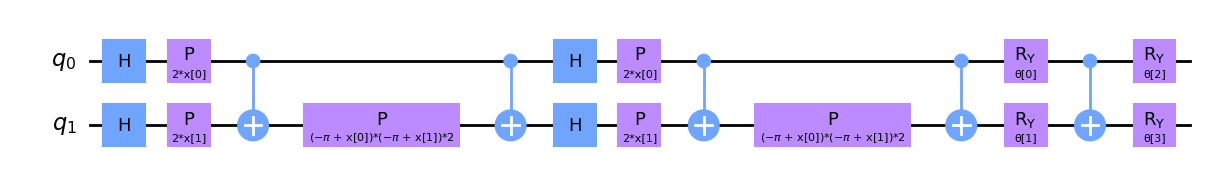

In [21]:
from qiskit.circuit.library import real_amplitudes

qc, fm_params, anz_params = qnn_circuit(ansatz=real_amplitudes(num_inputs, reps=1))
qc.draw("mpl", style="clifford")

A função `parity` define o mapeamento das bitstrings para as classes. O `output_shape`
igual a 2 corresponde ao número de classes possíveis após esse mapeamento.

In [22]:
def parity(x):
    return "{:b}".format(x).count("1") % 2

output_shape = 2  # número de classes

A `SamplerQNN` é criada com a função `interpret=parity` e o `output_shape`, usando o
`StatevectorSampler` para simulação local.

In [23]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN

sampler = Sampler()
sampler_qnn = SamplerQNN(
    circuit=qc,
    input_params=fm_params,
    weight_params=anz_params,
    interpret=parity,
    output_shape=output_shape,
    sampler=sampler,
)

O classificador é montado em torno dessa QNN, reutilizando a mesma função de callback.
Desta vez o `COBYLA` usa no máximo 30 iterações.

In [24]:
sampler_classifier = NeuralNetworkClassifier(
    neural_network=sampler_qnn, optimizer=COBYLA(maxiter=30), callback=callback_graph
)

O treinamento usa os rótulos `y01` (em {0, 1}), já que a paridade produz índices de
classe 0 ou 1.

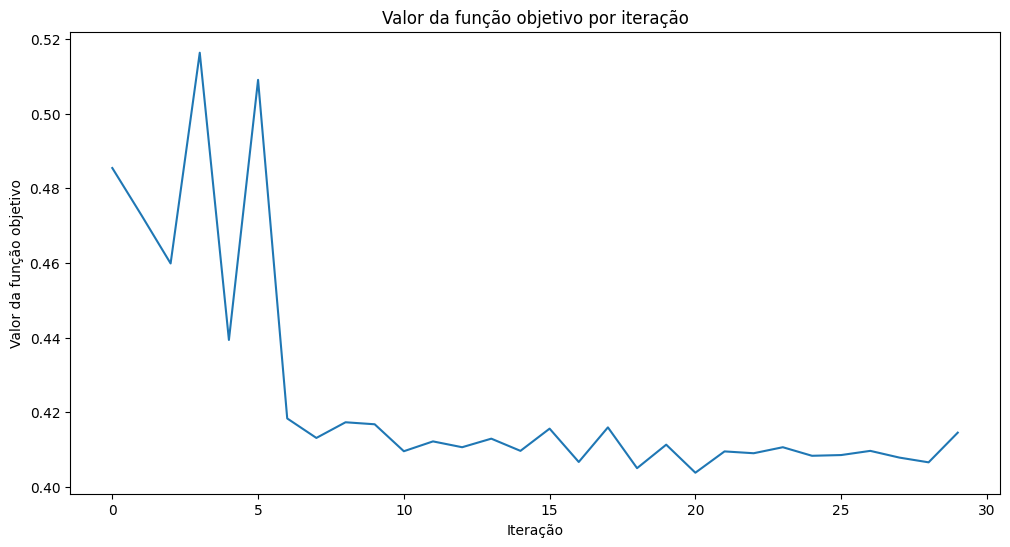

Acurácia no treino (SamplerQNN): 70.0%


In [25]:
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

sampler_classifier.fit(X, y01)

plt.rcParams["figure.figsize"] = (6, 4)

acc = sampler_classifier.score(X, y01)
resultados_classificacao["SamplerQNN"] = acc
print(f"Acurácia no treino (SamplerQNN): {acc:.1%}")

Como antes, os pontos classificados incorretamente são destacados com um círculo vermelho.

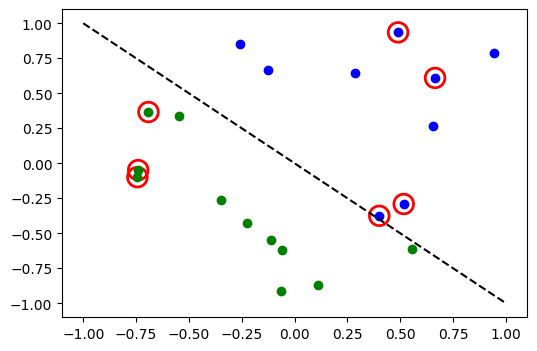

In [26]:
y_predict = sampler_classifier.predict(X)

for x, y_target, y_p in zip(X, y01, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

Como o ansatz foi definido com `reps=1`, o modelo tem menos pesos que o do exemplo anterior.

In [27]:
sampler_classifier.weights

array([1.78511087, 1.50520371, 1.56880441, 1.75847869])

### 4.3. Classificador Quântico Variacional (`VQC`)

O `VQC` é uma variante especial do `NeuralNetworkClassifier` que já usa uma `SamplerQNN`
internamente. Ele aplica o mapeamento de paridade (ou extensões para múltiplas classes)
e interpreta a saída como um vetor de probabilidades em codificação one-hot. Por padrão
usa a função de perda `CrossEntropyLoss`, que espera os rótulos em formato one-hot e
também retorna as previsões nesse formato. Aqui o feature map e o ansatz são passados
explicitamente.

In [28]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.algorithms.classifiers import VQC

feature_map = zz_feature_map(num_inputs)
ansatz = real_amplitudes(num_inputs, reps=1)

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

Diferente dos exemplos anteriores, o `VQC` monta o circuito internamente. Para
visualizá-lo, basta compor o feature map com o ansatz, que é exatamente a estrutura
usada pelo classificador.

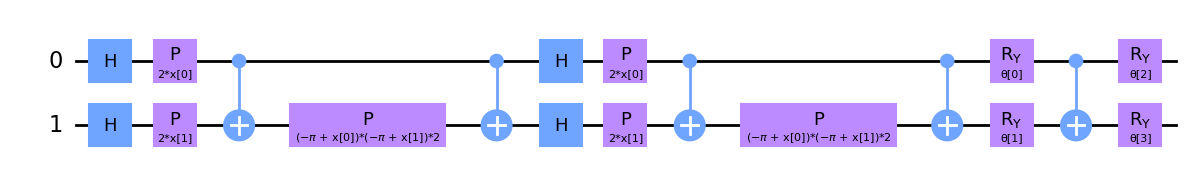

In [29]:
vqc_circuit = feature_map.compose(ansatz)
vqc_circuit.draw("mpl", style="clifford")

O treinamento usa os rótulos em formato one-hot (`y_one_hot`).

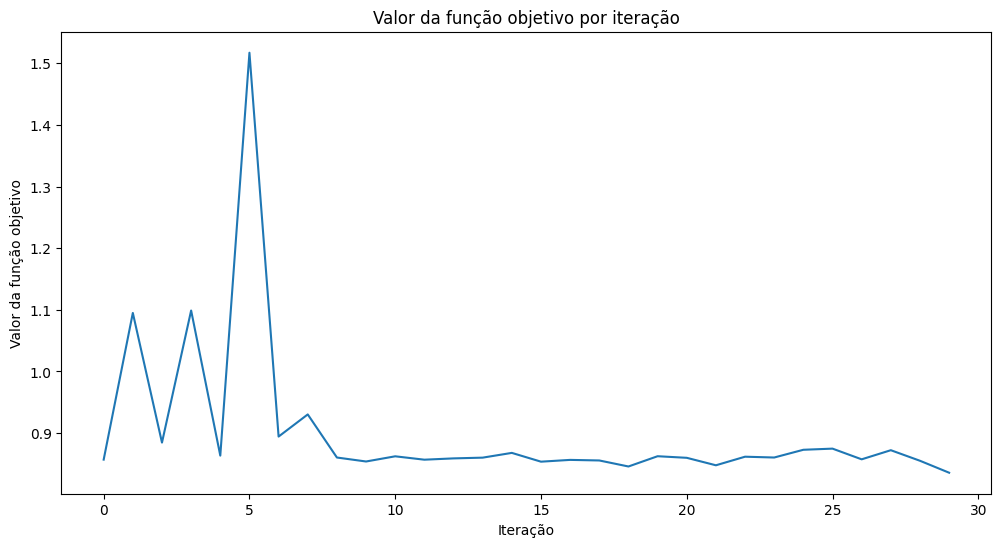

Acurácia no treino (VQC binário): 60.0%


In [30]:
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

vqc.fit(X, y_one_hot)

plt.rcParams["figure.figsize"] = (6, 4)

acc = vqc.score(X, y_one_hot)
resultados_classificacao["VQC binário"] = acc
print(f"Acurácia no treino (VQC binário): {acc:.1%}")

Na visualização, um ponto é considerado incorreto quando o vetor one-hot previsto difere
do esperado.

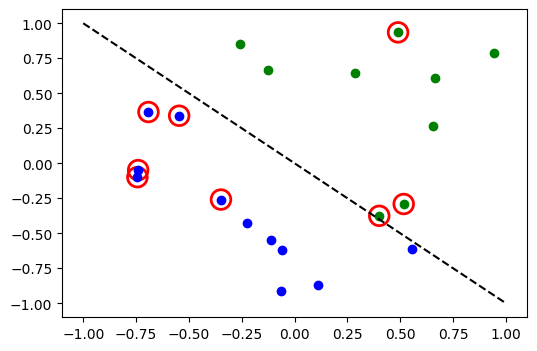

In [31]:
y_predict = vqc.predict(X)

for x, y_target, y_p in zip(X, y_one_hot, y_predict):
    if y_target[0] == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if not np.all(y_target == y_p):
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### 4.4. Múltiplas classes com o `VQC`

Os exemplos anteriores eram binários. Esta seção mostra como o `VQC` lida com mais de
duas classes. É gerado um dataset artificial com `make_classification` do scikit-learn:
10 amostras, 2 atributos (para permitir a visualização), nenhuma feature redundante,
3 classes e separação entre classes de 2.0 (um pouco acima do padrão 1.0, para facilitar
o problema). Em seguida os atributos são reescalados para o intervalo [0, 1].

In [32]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler

X, y = make_classification(
    n_samples=10,
    n_features=2,
    n_classes=3,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=algorithm_globals.random_seed,
)
X = MinMaxScaler().fit_transform(X)

O gráfico abaixo mostra as três classes, cada uma com uma cor.

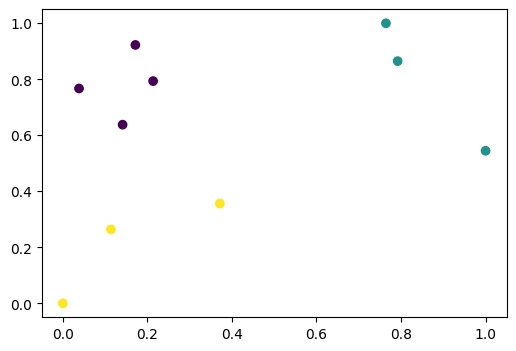

In [33]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

Para demonstrar que o `VQC` aceita rótulos não numéricos, os rótulos são convertidos para
categorias de texto: A, B e C.

In [34]:
y_cat = np.empty(y.shape, dtype=str)
y_cat[y == 0] = "A"
y_cat[y == 1] = "B"
y_cat[y == 2] = "C"
print(y_cat)

['A' 'A' 'B' 'C' 'C' 'A' 'B' 'B' 'A' 'C']


Desta vez o `VQC` é criado de forma mínima: em vez de passar feature map e ansatz,
passa-se apenas o número de qubits (igual ao número de atributos). O `VQC` usa, por
padrão, o `zz_feature_map` e o `real_amplitudes`.

In [35]:
vqc = VQC(
    num_qubits=2,
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

Mesmo passando apenas o número de qubits, é possível inspecionar o circuito que o `VQC`
montou internamente.

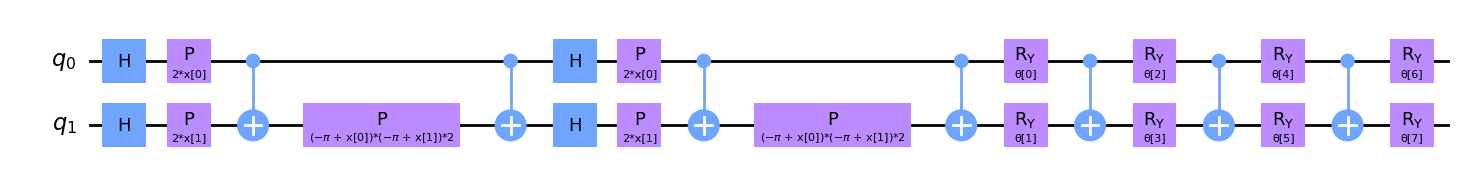

In [36]:
vqc.neural_network.circuit.draw("mpl", style="clifford")

O treinamento segue o mesmo padrão dos exemplos anteriores, agora com os rótulos
categóricos.

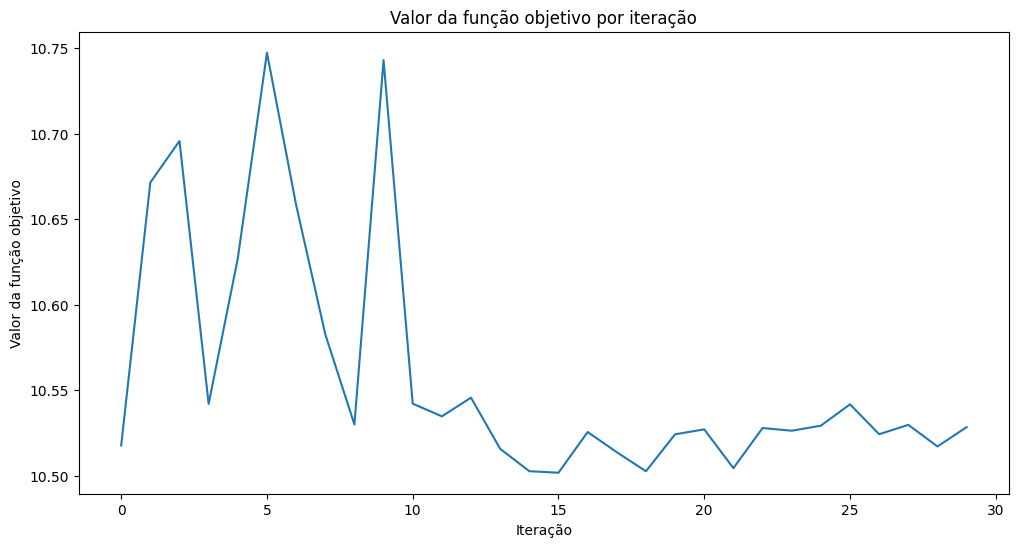

Acurácia no treino (VQC multiclasse): 40.0%


In [37]:
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

vqc.fit(X, y_cat)

plt.rcParams["figure.figsize"] = (6, 4)

acc = vqc.score(X, y_cat)
resultados_classificacao["VQC multiclasse"] = acc
print(f"Acurácia no treino (VQC multiclasse): {acc:.1%}")

Por fim, as previsões são comparadas com os rótulos verdadeiros.

In [38]:
predict = vqc.predict(X)
print(f"Rótulos previstos: {predict}")
print(f"Rótulos reais:     {y_cat}")

Rótulos previstos: ['B' 'B' 'B' 'B' 'B' 'A' 'B' 'B' 'B' 'B']
Rótulos reais:     ['A' 'A' 'B' 'C' 'C' 'A' 'B' 'B' 'A' 'C']


### 4.5. Comparação dos classificadores

A acurácia de cada modelo foi guardada durante o treino. O gráfico abaixo compara os
quatro classificadores. Vale notar que os três primeiros resolvem o mesmo problema
binário (20 amostras), enquanto o VQC multiclasse resolve um problema diferente e mais
difícil (3 classes, 10 amostras), então a comparação é apenas ilustrativa.

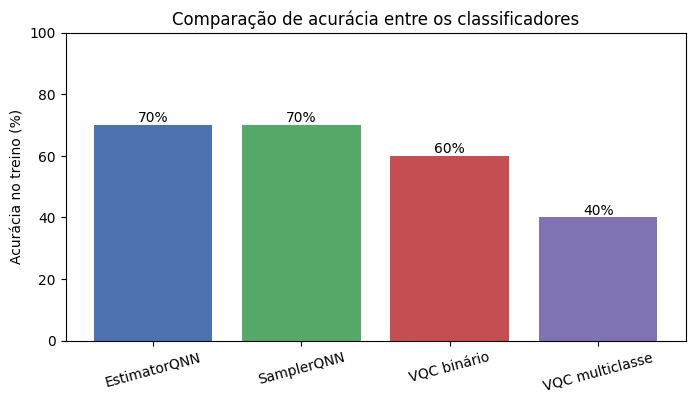

In [39]:
nomes = list(resultados_classificacao.keys())
valores = [resultados_classificacao[k] * 100 for k in nomes]

plt.figure(figsize=(8, 4))
barras = plt.bar(nomes, valores, color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"])
plt.ylabel("Acurácia no treino (%)")
plt.title("Comparação de acurácia entre os classificadores")
plt.ylim(0, 100)
for b, v in zip(barras, valores):
    plt.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}%", ha="center")
plt.xticks(rotation=15)
plt.show()

**Como melhorar a acurácia (e o que vem junto)**

Os resultados acima são modestos porque os exemplos usam datasets pequenos e poucos
passos de otimização, escolhidos para treinar rápido. Existem várias formas de melhorar
a acurácia, mas cada uma traz um custo ou uma dificuldade:

- **Aumentar o número de iterações do otimizador** (por exemplo, um `maxiter` maior no
  `COBYLA`). Tende a melhorar o ajuste, mas aumenta o tempo de treino e, em datasets
  pequenos, pode levar a overfitting, quando o modelo decora os dados de treino e
  generaliza pior.
- **Usar um ansatz mais expressivo** (mais `reps` ou mais camadas). Adiciona parâmetros
  treináveis e capacidade de representação, porém torna a otimização mais difícil e cara,
  e aumenta o risco de barren plateaus, regiões em que os gradientes ficam praticamente
  nulos e o treino estagna.
- **Aumentar a quantidade de dados de treino**. Melhora a generalização, mas cada amostra
  exige novas avaliações do circuito, então o custo computacional cresce de forma
  proporcional, ainda mais em hardware real.
- **Aumentar o número de qubits ou trocar o feature map**. Pode codificar os dados de
  forma mais rica, mas a simulação clássica fica exponencialmente mais pesada, e em
  hardware real surgem mais ruído e limitações de conectividade entre os qubits.
- **Trocar o otimizador** (por exemplo, métodos baseados em gradiente como `L-BFGS-B`).
  Pode convergir melhor, mas o cálculo dos gradientes exige muitas avaliações adicionais
  do circuito.

No fundo, há um equilíbrio entre expressividade, treinabilidade e custo: modelos mais
poderosos são mais difíceis e caros de treinar. Essas limitações são retomadas em
detalhe na seção de Performance.

## 5. Regressão

Esta seção aplica as QNNs em regressão, ou seja, prever um valor contínuo em vez de uma
classe. O conjunto de dados é gerado a partir da função seno, com um pequeno ruído
adicionado aos pontos de treino. A linha tracejada vermelha é a função verdadeira e os
pontos azuis são as amostras de treino.

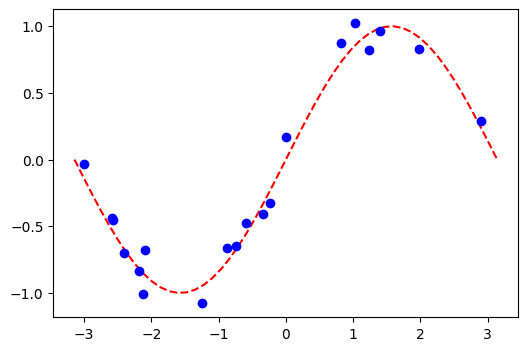

In [40]:
num_samples = 20
eps = 0.2
lb, ub = -np.pi, np.pi
X_ = np.linspace(lb, ub, num=50).reshape(50, 1)
f = lambda x: np.sin(x)

X = (ub - lb) * algorithm_globals.random.random([num_samples, 1]) + lb
y = f(X[:, 0]) + eps * (2 * algorithm_globals.random.random(num_samples) - 1)

plt.plot(X_, f(X_), "r--")
plt.plot(X, y, "bo")
plt.show()

### 5.1. Regressão com `EstimatorQNN`

Aqui a regressão usa uma `EstimatorQNN`, que retorna valores em [-1, +1]. O feature map e
o ansatz são circuitos simples de 1 qubit, cada um com uma rotação `RY`: o feature map
codifica a entrada e o ansatz contém o peso treinável.

In [41]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

# feature map: codifica a entrada
param_x = Parameter("x")
feature_map = QuantumCircuit(1, name="fm")
feature_map.ry(param_x, 0)

# ansatz: contém o peso treinável
param_y = Parameter("y")
ansatz = QuantumCircuit(1, name="vf")
ansatz.ry(param_y, 0)

# monta o circuito completo
qc, fm_params, anz_params = qnn_circuit(feature_map=feature_map, ansatz=ansatz)

regression_estimator_qnn = EstimatorQNN(
    circuit=qc, input_params=fm_params, weight_params=anz_params, estimator=estimator
)

O circuito resultante (feature map seguido do ansatz):

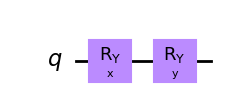

In [42]:
qc.draw("mpl", style="clifford")

O `NeuralNetworkRegressor` envolve a QNN. Usa a perda de erro quadrático
(`squared_error`) e o otimizador `L_BFGS_B`, que é baseado em gradiente.

In [43]:
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor
from qiskit_machine_learning.optimizers import L_BFGS_B

regressor = NeuralNetworkRegressor(
    neural_network=regression_estimator_qnn,
    loss="squared_error",
    optimizer=L_BFGS_B(maxiter=5),
    callback=callback_graph,
)

O treinamento segue o mesmo padrão. O `score` de um regressor é o coeficiente de
determinação R², em que 1.0 representa o ajuste perfeito.

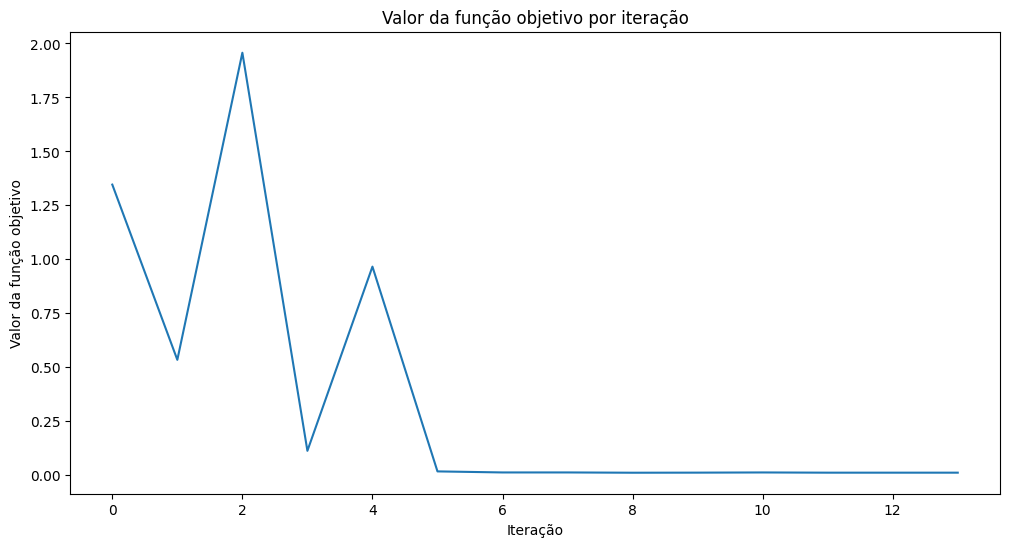

R² no treino (EstimatorQNN): 0.974


In [44]:
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

regressor.fit(X, y)

plt.rcParams["figure.figsize"] = (6, 4)

score = regressor.score(X, y)
print(f"R² no treino (EstimatorQNN): {score:.3f}")

O gráfico abaixo mostra a função verdadeira (tracejado vermelho), os pontos de treino
(azul) e a curva ajustada pelo modelo (verde).

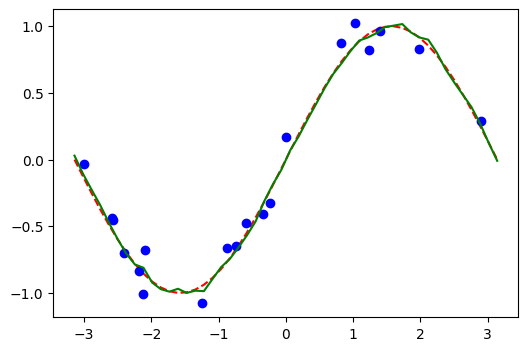

In [45]:
plt.plot(X_, f(X_), "r--")
plt.plot(X, y, "bo")
y_ = regressor.predict(X_)
plt.plot(X_, y_, "g-")
plt.show()

Como o ansatz tem apenas um parâmetro, o modelo tem um único peso treinável.

In [46]:
regressor.weights

array([-1.58697461])

### 5.2. Regressão com o `VQR` (Variational Quantum Regressor)

Assim como o `VQC` para classificação, o `VQR` é uma variante pronta do
`NeuralNetworkRegressor` que usa uma `EstimatorQNN` internamente. Por padrão, minimiza o
erro quadrático médio entre previsões e alvos. Aqui são reaproveitados o mesmo feature
map e ansatz definidos no exemplo anterior.

In [47]:
from qiskit_machine_learning.algorithms.regressors import VQR

vqr = VQR(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=5),
    callback=callback_graph,
    estimator=estimator,
)

O circuito do `VQR` é a composição do feature map com o ansatz:

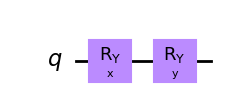

In [48]:
vqr_circuit = feature_map.compose(ansatz)
vqr_circuit.draw("mpl", style="clifford")

Treino e avaliação do `VQR`, no mesmo formato do exemplo anterior.

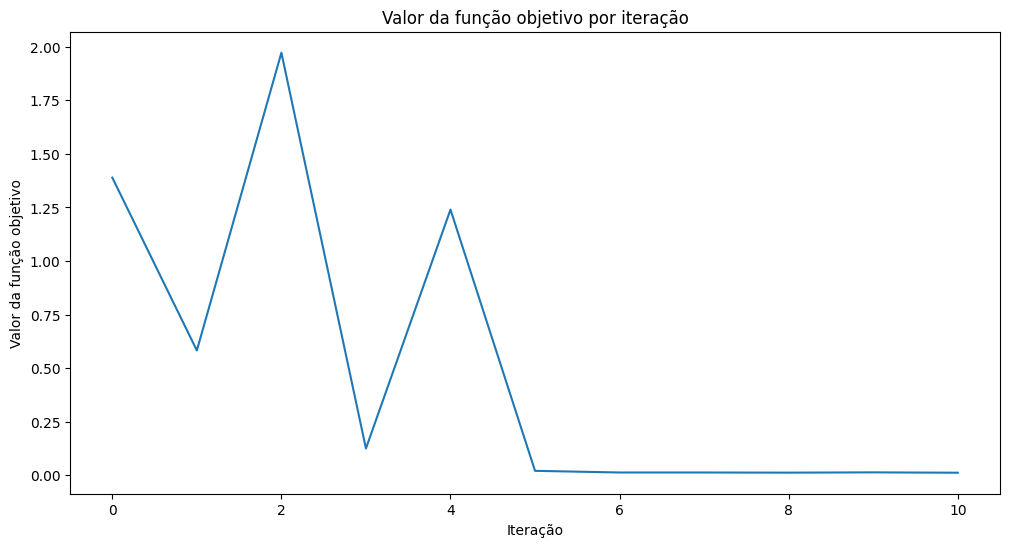

R² no treino (VQR): 0.973


In [49]:
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

vqr.fit(X, y)

plt.rcParams["figure.figsize"] = (6, 4)

score = vqr.score(X, y)
print(f"R² no treino (VQR): {score:.3f}")

E o ajuste do `VQR` sobre os dados, com a função verdadeira (tracejado vermelho), os
pontos de treino (azul) e a curva ajustada (verde).

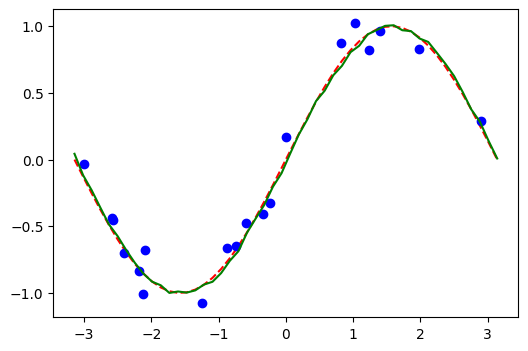

In [50]:
plt.plot(X_, f(X_), "r--")
plt.plot(X, y, "bo")
y_ = vqr.predict(X_)
plt.plot(X_, y_, "g-")
plt.show()

## 6. Aplicação em dados reais e o efeito do ruído (Iris)

Esta seção tem dois objetivos didáticos. Primeiro, sair dos dados sintéticos e aplicar
o classificador a um **conjunto de dados real**: o Iris, um clássico de medições reais de
flores. Segundo, mostrar o **efeito do ruído**, treinando o mesmo modelo num simulador
ideal e num simulador com ruído que imita um chip quântico real.

Para manter o exemplo leve e claro, são usadas duas espécies fáceis de separar (setosa e
versicolor) e apenas os dois atributos de pétala, com 50 amostras divididas em treino e
teste.

### Por que um simulador ruidoso, e não hardware real?

Esta demonstração usa um chip simulado com ruído (um *fake device*) em vez de um computador
quântico real, por uma escolha prática. Treinar um modelo variacional exige muitas
avaliações do circuito, e em hardware real cada execução enfrenta fila de espera e consome
o tempo de acesso gratuito, que é limitado, o que tornaria o treino completo inviável dentro
do prazo. Além disso, o resultado do hardware muda a cada execução conforme a calibração do
chip, o que quebraria a reprodutibilidade do notebook.

O fake device resolve os dois problemas ao mesmo tempo: ele reproduz o ruído e a
conectividade característicos de um chip real, mas roda localmente, de graça e de forma
reprodutível, com a semente fixada. Assim, o efeito do ruído é mostrado de forma honesta e
repetível, sem depender de acesso a hardware.

In [51]:
!pip install -q qiskit-aer==0.17.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.2 MB/s eta 0:00:00


Os dados são filtrados para as duas espécies e os dois atributos de pétala, reduzidos a
25 amostras por espécie, normalizados para [0, 1] e divididos em treino (70%) e teste
(30%). Os rótulos são convertidos para {-1, +1}, formato esperado pela `EstimatorQNN`.

In [52]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

iris = load_iris()
# espécies 0 (setosa) e 1 (versicolor), atributos de pétala (índices 2 e 3)
mask = iris.target < 2
X_iris = iris.data[mask][:, [2, 3]]
y_iris = iris.target[mask]

# 25 amostras por espécie (50 no total)
idx0 = np.where(y_iris == 0)[0][:25]
idx1 = np.where(y_iris == 1)[0][:25]
sel = np.concatenate([idx0, idx1])
X_iris, y_iris = X_iris[sel], y_iris[sel]

# normaliza e converte rótulos para {-1, +1}
X_iris = MinMaxScaler().fit_transform(X_iris)
y_pm = 2 * y_iris - 1

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_pm, test_size=0.3, random_state=algorithm_globals.random_seed, stratify=y_pm
)
print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 35 amostras | Teste: 15 amostras


As duas espécies, nos atributos de pétala. A separação é clara, o que dá uma linha de base
limpa para depois medir o efeito do ruído.

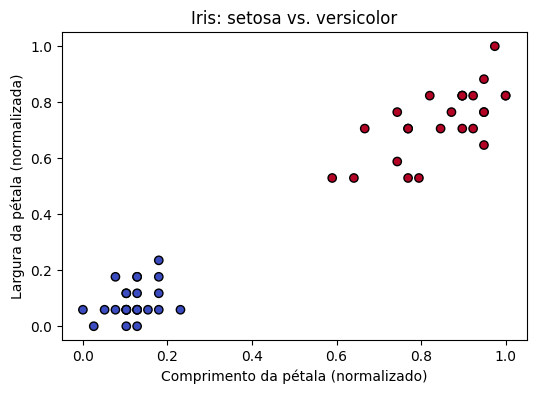

In [53]:
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap="coolwarm", edgecolors="k")
plt.xlabel("Comprimento da pétala (normalizado)")
plt.ylabel("Largura da pétala (normalizada)")
plt.title("Iris: setosa vs. versicolor")
plt.show()

Primeiro o treino no simulador **ideal** (sem ruído), com a `EstimatorQNN` e o `COBYLA`,
igual ao exemplo da Parte 4. A acurácia é medida no conjunto de teste.

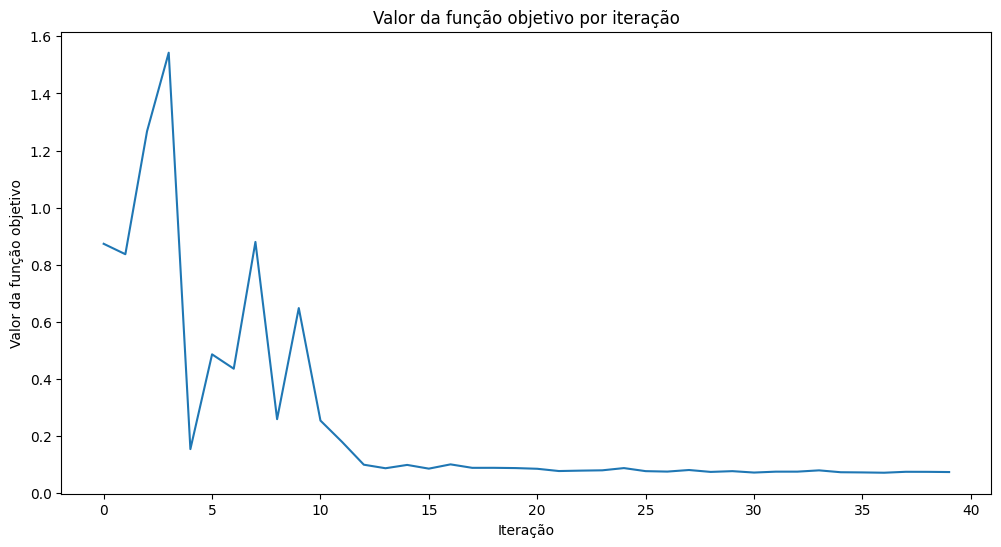

Acurácia no teste (ideal): 100.0%


In [54]:
from qiskit.primitives import StatevectorEstimator

qc_iris, fm_iris, anz_iris = qnn_circuit(num_qubits=2)

estimator_ideal = StatevectorEstimator()
qnn_ideal = EstimatorQNN(
    circuit=qc_iris, input_params=fm_iris, weight_params=anz_iris, estimator=estimator_ideal
)
clf_ideal = NeuralNetworkClassifier(qnn_ideal, optimizer=COBYLA(maxiter=40), callback=callback_graph)

objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)
clf_ideal.fit(X_train, y_train)
plt.rcParams["figure.figsize"] = (6, 4)

curva_ideal = list(objective_func_vals)
acc_ideal = clf_ideal.score(X_test, y_test)
print(f"Acurácia no teste (ideal): {acc_ideal:.1%}")

Agora o mesmo treino, mas com ruído. Um chip falso de 2 qubits (`GenericBackendV2`) fornece
um modelo de ruído realista, que é injetado no `EstimatorV2` do Aer (simulação por matriz
densidade). Tudo o mais é idêntico ao caso ideal. Esta célula é mais lenta, pois a
simulação com ruído é mais pesada.

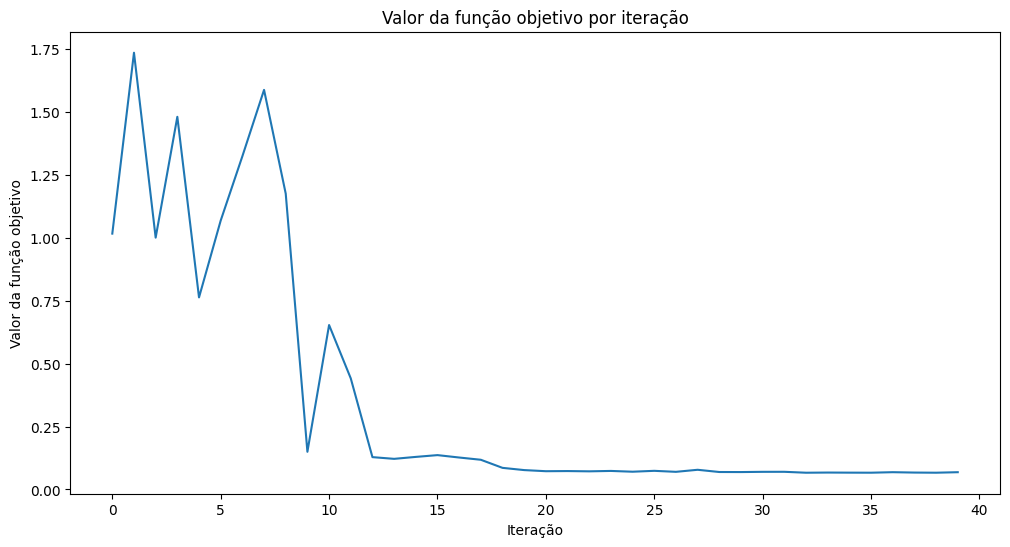

Acurácia no teste (ruidoso): 100.0%


In [55]:
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel
from qiskit.providers.fake_provider import GenericBackendV2

# chip falso de 2 qubits e seu modelo de ruído
coupling_map = [(0, 1)]
device = GenericBackendV2(num_qubits=2, coupling_map=coupling_map, seed=54)
noise_model = NoiseModel.from_backend(device)

# estimator ruidoso: o modelo de ruído entra via backend_options
# seed_simulator deixa o resultado reprodutível
estimator_noisy = AerEstimator(
    options={
        "default_precision": 1e-2,
        "backend_options": {
            "method": "density_matrix",
            "coupling_map": coupling_map,
            "noise_model": noise_model,
            "seed_simulator": algorithm_globals.random_seed,
        },
    }
)
qnn_noisy = EstimatorQNN(
    circuit=qc_iris, input_params=fm_iris, weight_params=anz_iris, estimator=estimator_noisy
)
clf_noisy = NeuralNetworkClassifier(qnn_noisy, optimizer=COBYLA(maxiter=40), callback=callback_graph)

objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)
clf_noisy.fit(X_train, y_train)
plt.rcParams["figure.figsize"] = (6, 4)

curva_ruidosa = list(objective_func_vals)
acc_noisy = clf_noisy.score(X_test, y_test)
print(f"Acurácia no teste (ruidoso): {acc_noisy:.1%}")

Comparação direta entre os dois: a acurácia no teste e a curva de convergência do treino.

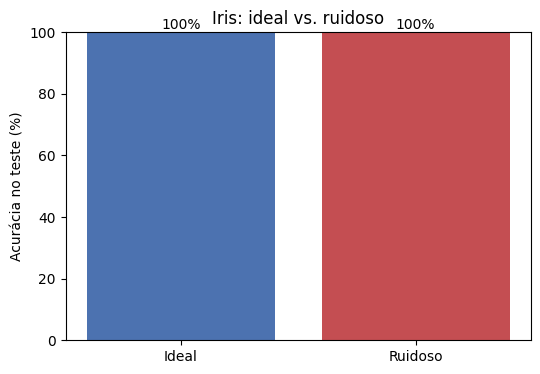

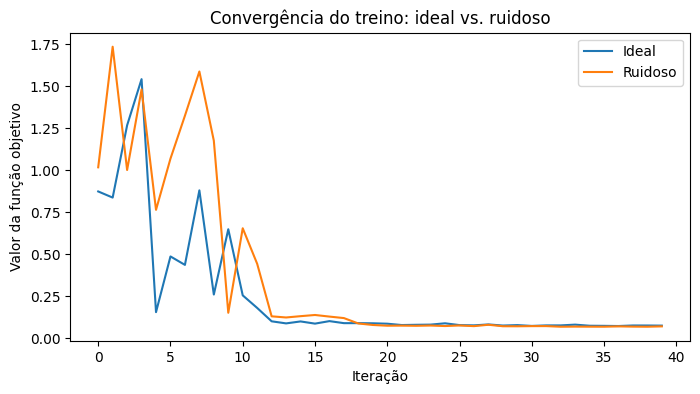

In [56]:
# acurácia
plt.figure(figsize=(6, 4))
vals = [acc_ideal * 100, acc_noisy * 100]
barras = plt.bar(["Ideal", "Ruidoso"], vals, color=["#4C72B0", "#C44E52"])
plt.ylabel("Acurácia no teste (%)")
plt.title("Iris: ideal vs. ruidoso")
plt.ylim(0, 100)
for b, v in zip(barras, vals):
    plt.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}%", ha="center")
plt.show()

# convergência
plt.figure(figsize=(8, 4))
plt.plot(curva_ideal, label="Ideal")
plt.plot(curva_ruidosa, label="Ruidoso")
plt.xlabel("Iteração")
plt.ylabel("Valor da função objetivo")
plt.title("Convergência do treino: ideal vs. ruidoso")
plt.legend()
plt.show()

Os dois modelos chegaram a 100% de acurácia no teste, mas isso não significa que o ruído
não teve efeito. Como o problema é fácil, com as duas espécies bem separáveis, a margem de
decisão é larga, então mesmo um treino ruidoso ainda encontra uma solução que acerta tudo.

O efeito do ruído aparece com clareza na **curva de convergência**: a versão ruidosa é bem
mais instável e demora mais para baixar, porque cada avaliação da função objetivo carrega
erro. Em problemas mais difíceis ou com ruído mais forte, essa instabilidade passaria a
derrubar também a acurácia final.

Isso ilustra a limitação central do QML na era atual (NISQ): o ruído do hardware degrada o
processo de treino, e técnicas de mitigação de erro seriam necessárias para reduzir esse
efeito.

## 7. Metodologia

Antes da análise, uma classificação do tema. Neural Network Classifier & Regressor é um
tema de **Quantum Machine Learning (QML)**, e não de otimização quântica. Ele usa redes
neurais quânticas (QNNs) para tarefas de aprendizado supervisionado, ou seja,
classificação e regressão.

### 7.1. Quanto à instalação

Além do `qiskit` (núcleo), o tema depende do pacote `qiskit-machine-learning`, que fornece
as QNNs (`EstimatorQNN`, `SamplerQNN`), os classificadores e regressores
(`NeuralNetworkClassifier`, `VQC`, `NeuralNetworkRegressor`, `VQR`) e os otimizadores
(`COBYLA`, `L_BFGS_B`). Para a demonstração de ruído foi necessário também o `qiskit-aer`,
o simulador de alto desempenho, e para desenhar os circuitos o `pylatexenc`.

Sim, o tema necessita de bibliotecas clássicas de ML. O `scikit-learn` foi usado para gerar
e preparar dados (`make_classification`, `load_iris`, `MinMaxScaler`, `train_test_split`),
e o `numpy` e o `matplotlib` para manipulação numérica e gráficos. Isso reflete uma
característica central do QML atual: ele é **híbrido**, e se apoia fortemente no ferramental
clássico de machine learning para dados, pré-processamento e otimização.

As versões dessas bibliotecas foram travadas na célula de instalação para garantir a
reprodutibilidade, já que a API do Qiskit muda com frequência entre versões.

### 7.2. Quanto à IDE

O trabalho foi desenvolvido no **Google Colab (versão Pro)**. As alternativas consideradas
foram o Jupyter Notebook local e o VS Code. O Jupyter local exige instalar e gerenciar o
ambiente Python na própria máquina, o que pode gerar conflitos de versão. O VS Code é
excelente para projetos de código maiores, mas tem mais configuração inicial e é menos
prático para um documento com texto, código e gráficos intercalados.

O Colab foi a melhor opção para este trabalho específico por três motivos. Primeiro, roda
no navegador sem nenhuma instalação local, bastando a célula de `pip` para montar o
ambiente exato. Segundo, o resultado é um `.ipynb` fácil de compartilhar e reabrir.
Terceiro, o ambiente já vem com as bibliotecas clássicas (numpy, scikit-learn, matplotlib)
prontas. A versão Pro acrescentou estabilidade, com sessões mais longas e menos
desconexões, embora a tarefa não exija GPU, pois a simulação quântica desta escala roda em
CPU.

### 7.3. Quanto à utilização

**O tema está claro no tutorial da IBM?** No geral, sim. Os tutoriais são bem estruturados,
com exemplos progressivos e explicações razoáveis. Mas há ressalvas honestas. A última
célula importa um módulo `tutorial_magics` que só existe no ambiente de documentação da IBM
e quebra em qualquer outro lugar. A API usada é recente, então é preciso acertar as versões
das bibliotecas para o código rodar. E funções como o `qnn_circuit` abstraem bastante a
montagem do circuito, o que é conveniente mas esconde detalhes de quem está aprendendo.
Conceitos como passagem direta e reversa, e o mapeamento de paridade, exigem alguma base
prévia.

**Quantidade de portas e complexidade do circuito.** Os circuitos combinam um feature map e
um ansatz. O `zz_feature_map` usa portas Hadamard e rotações de entrelaçamento entre pares
de qubits. O `real_amplitudes` usa rotações `RY` intercaladas com portas `CX`. Para 2
qubits o número de portas é modesto, mas ele cresce com o número de qubits e com o parâmetro
`reps` (repetições de camadas do ansatz). A complexidade dominante, porém, não é o circuito
em si, e sim o treino variacional: cada iteração do otimizador avalia o circuito muitas
vezes, uma por amostra, então o custo total é proporcional ao número de amostras vezes o
número de iterações.

**Limite de qubits.** O limite prático não vem do algoritmo, que em princípio escala para
muitos qubits, mas do custo de memória da simulação clássica, e por isso depende da RAM
disponível. A simulação ideal por vetor de estado guarda 2 elevado a n amplitudes, cada uma
ocupando 16 bytes. Assim, 29 qubits ocupam cerca de 8 GB e 30 qubits cerca de 16 GB, o que
coloca o teto em torno de 30 qubits numa sessão típica do Colab. A simulação ruidosa por
matriz densidade é bem mais cara, pois guarda 4 elevado a n elementos: 14 qubits já ocupam
cerca de 4 GB e 15 qubits cerca de 16 GB, o que reduz o teto para cerca de 14 qubits no
mesmo ambiente. Esses valores são aproximados e variam com a RAM da máquina. Os exemplos
deste notebook usaram apenas 1 a 2 qubits. Em hardware real há mais qubits disponíveis, mas
aí o limite deixa de ser a memória e passa a ser o ruído e a conectividade, discutidos na
próxima seção.

## 8. Performance

### 8.1. Demonstração com exemplos práticos

O desempenho foi demonstrado ao longo das Partes 4, 5 e 6. Na classificação, os quatro
modelos (EstimatorQNN, SamplerQNN, VQC binário e VQC multiclasse) alcançaram acurácias na
faixa de 60% a 75% em conjuntos de dados pequenos e com poucas iterações de otimização,
valores escolhidos para um treino rápido. Na regressão, tanto a `EstimatorQNN` quanto o
`VQR` ajustaram a função seno com R² em torno de 0,97, um resultado muito bom. No exemplo
com dados reais (Iris), o classificador atingiu 100% de acurácia no teste, por ser um
problema bem separável.

Esses resultados mostram que os métodos funcionam e resolvem as tarefas propostas. As
acurácias modestas da classificação não refletem uma falha do método, e sim as escolhas
deliberadas de datasets pequenos e poucas iterações para manter o notebook leve. Como
discutido ao final da Parte 4, mais dados e mais iterações tendem a melhorar a acurácia, ao
custo de mais processamento.

### 8.2. Limitações para a praticidade no mundo real

A pergunta sobre as limitações tem mais de uma resposta. A quantidade de qubits é um fator,
mas não o único.

**Quantidade de qubits.** Na simulação clássica, o limite é a memória, como detalhado na
Parte 7. Em hardware real, o número de qubits é limitado e a coerência, que é o tempo que o
qubit mantém seu estado, é curta.

**Conectividade.** Os qubits de um chip real só interagem diretamente com seus vizinhos.
Quando o algoritmo precisa de uma porta de dois qubits entre qubits não conectados, o
compilador insere portas SWAP, que aumentam o número de portas e, com isso, o ruído
acumulado. Foi por isso que o exemplo da Parte 6 incluiu um mapa de conectividade no modelo
de ruído.

**Ruído.** É a limitação central da era NISQ. Erros de porta, decoerência e erros de leitura
se acumulam ao longo do circuito, e o efeito foi visto na prática na Parte 6: mesmo sem
derrubar a acurácia no problema fácil, o ruído deixou o treino bem mais instável. Em
problemas mais difíceis, esse efeito tende a degradar também o resultado final.

**Treinabilidade.** Há ainda os barren plateaus, regiões em que os gradientes ficam
praticamente nulos quando o circuito cresce em qubits e profundidade, o que torna a
otimização cada vez mais difícil à medida que o modelo aumenta.

### 8.3. O que falta ou precisa de otimização

Para o tema performar melhor no mundo real, alguns pontos precisam evoluir.

**Mitigação e correção de erros**, para reduzir o impacto do ruído sem depender de um
hardware perfeito.

**Hardware melhor**, com mais qubits, maior conectividade, menos ruído e maior tempo de
coerência.

**Ansätze mais adequados**, desenhados para o problema ou para o hardware, que sejam
expressivos mas evitem os barren plateaus.

**Otimizadores mais eficientes**, que cheguem a uma boa solução com menos avaliações de
circuito, já que esse é o gargalo de custo do treino variacional.

**Codificação de dados que escale**, porque carregar dados clássicos em estados quânticos é,
em si, um ponto caro e limitante.

Por fim, ainda é uma questão em aberto demonstrar uma vantagem quântica clara sobre os
melhores métodos clássicos em dados do mundo real. Os resultados atuais são promissores como
prova de conceito, mas a superioridade prática ainda não está estabelecida.

## 9. Conclusão

### 9.1. Tabela de pontos positivos e negativos

| Pontos positivos | Pontos negativos |
|---|---|
| API de alto nível (`qnn_circuit`, `VQC`, `VQR`) simplifica a montagem dos modelos | O ruído da era NISQ degrada o treino e o desempenho |
| Integra-se ao ferramental clássico de ML (scikit-learn, numpy) | A simulação clássica é limitada pela memória (poucas dezenas de qubits) |
| A mesma estrutura serve para classificação e regressão | A conectividade limitada do hardware exige portas SWAP extras |
| Tutoriais bem estruturados e didáticos | Os barren plateaus dificultam treinar modelos maiores |
| A simulação local permite aprender sem hardware real | O treino variacional é caro, com muitas avaliações de circuito |
| Reprodutível com versões travadas | A vantagem quântica prática ainda não foi comprovada |

### 9.2. Viés didático

O roteiro propõe a pergunta: é possível criar um tutorial com viés mais didático? A resposta
deste trabalho é sim, e o próprio notebook é essa tentativa. Em relação aos tutoriais
originais da IBM, foram acrescentados explicações em português antes e depois de cada bloco
de código, desenhos de todos os circuitos, a impressão da acurácia em porcentagem, um
gráfico comparando os classificadores, e um exemplo com dados reais (o Iris) no lugar de
apenas dados sintéticos. A demonstração do efeito do ruído também foi adicionada para tornar
concreta uma limitação que normalmente fica só no discurso. O exemplo do Iris, em
particular, atende ao pedido de explorar situações reais via exemplos.

### 9.3. Direcionamento para pesquisa

O tema também pode ser direcionado para pesquisa de fronteira. QML é uma área ativa, e as
QNNs deste trabalho são blocos de construção para questões em aberto: o estudo de ansätze
mais expressivos que evitem os barren plateaus, técnicas de mitigação de erro para o treino
em hardware ruidoso, métodos de codificação de dados que escalem, e a busca por uma vantagem
quântica comprovada. O maior potencial de pesquisa está em problemas com estrutura
intrinsecamente quântica, como química e física, nos quais os dados já são quânticos por
natureza.

### 9.4. Análise resumida

Em resumo, o tema Neural Network Classifier & Regressor é uma porta de entrada acessível e
flexível para o QML. Seus pontos fortes são a API de alto nível, a integração com o
ferramental clássico e a versatilidade entre classificação e regressão. Seus pontos fracos
estão ligados à maturidade da tecnologia: ruído, limite de qubits, conectividade e a
dificuldade de treino em escala. A característica mais interessante é o seu caráter híbrido,
que combina circuitos quânticos parametrizados com otimização clássica, e o fato de que,
mesmo na era NISQ, já é possível treinar e avaliar modelos completos, ainda que em escala
reduzida. É uma tecnologia promissora e em evolução, cujo valor prático sobre os métodos
clássicos ainda está sendo construído.